# Attacking a Vision Language Model using the Image

In [1]:
# !pip install transformers matplotlib datasets

### Imports

In [2]:
from transformers import AutoProcessor, AutoTokenizer, AutoModelForImageTextToText, AutoModelForVision2Seq
from transformers.image_utils import load_image
from transformers.image_transforms import to_pil_image
import torch
from utils import get_device, plot_images
import torchvision.transforms as T
from attack import adversarial_attack_vlm_fgsm_iterative

In [3]:
device = get_device(prefer_mps=True)
vlm_model_name = "HuggingFaceTB/SmolVLM-256M-Instruct" # or "HuggingFaceTB/SmolVLM-256M-Instruct", 


processor = AutoProcessor.from_pretrained(vlm_model_name)
tokenizer = AutoTokenizer.from_pretrained(vlm_model_name)
# model = AutoModelForImageTextToText.from_pretrained(
model = AutoModelForVision2Seq.from_pretrained(
    vlm_model_name, 
    torch_dtype=torch.bfloat16,
    _attn_implementation="flash_attention_2" if device == "cuda" else "eager",).to(device)

the following should accelerate the code but can make accuracy drop 

In [4]:
processor.image_processor.do_image_splitting = False

### Load image

torch.Size([3, 480, 640]) tensor(255, dtype=torch.uint8) tensor(0, dtype=torch.uint8)


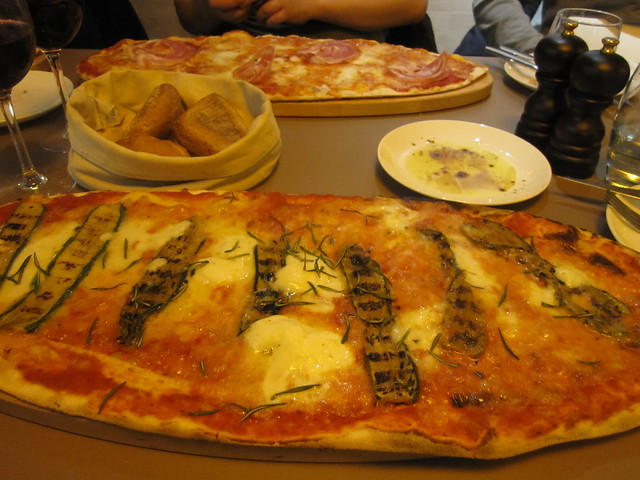

In [5]:
# image = load_image("https://cdn.britannica.com/61/93061-050-99147DCE/Statue-of-Liberty-Island-New-York-Bay.jpg")
image = load_image("https://farm9.staticflickr.com/8096/8445896722_e28fb3f055_z.jpg")
# image = load_image("https://raulperez.tieneblog.net/wp-content/uploads/2015/09/tux.jpg")
image_tensor = T.PILToTensor()(image)
print(image_tensor.shape, image_tensor.max(), image_tensor.min()) 
image

In [6]:
# Create input messages
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Can you describe this image?"}
        ]
    },
]

# Prepare inputs
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image], return_tensors="pt").to(device)
inputs['pixel_values'].shape, inputs['input_ids'].shape

(torch.Size([1, 1, 3, 512, 512]), torch.Size([1, 81]))

In [7]:
# only for testing
messages = [
    {
        "role": "user",
        "content": [{"type": "image"}]
    }
]
prompt = processor.apply_chat_template(messages, add_generation_prompt=False)
inputs_img = processor(text=prompt, images=[image], return_tensors="pt").to(device)
inputs_txt = processor(text=["a photo of a penguin"] , return_tensors="pt").to(device)

out_img = model(**inputs_img, output_hidden_states=True)
out_txt = model(**inputs_txt, output_hidden_states=True)
print(out_img.keys(), out_txt.keys())

print(out_img.image_hidden_states.shape, out_img.hidden_states[0].shape)
out_img.image_hidden_states[0][0][:10], out_img.hidden_states[0][0][5][:10] # these are the same

print(out_txt.hidden_states[0].shape)

odict_keys(['logits', 'past_key_values', 'hidden_states', 'image_hidden_states']) odict_keys(['logits', 'past_key_values', 'hidden_states'])
torch.Size([1, 64, 576]) torch.Size([1, 72, 576])
torch.Size([1, 5, 576])


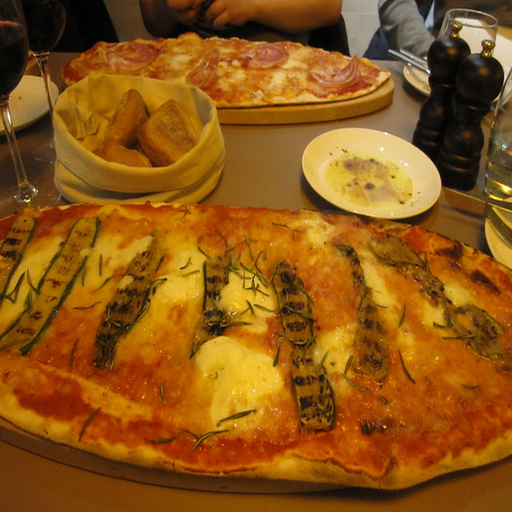

In [8]:
inputs_img['pixel_values'].shape
T.ToPILImage()(inputs_img['pixel_values'][0][0]/2+0.5)

In [9]:
# only for testing
messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Can you describe this image?"}
        ]
    },
    {
        "role": "assistant",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "I don't care"}
        ]
    },
]
print(processor(text="I dont't care")['input_ids'])
prompt = processor.apply_chat_template(messages, add_generation_prompt=False)
# n_tokens_target = len(processor())
inn = processor(text=prompt, images=[image], return_tensors="pt").to(device)
print(inn['input_ids'][0][-20:])
processor.batch_decode(inn['input_ids'])[0][-100:]

[[57, 35047, 982, 1176]]
tensor([49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190,
        49190, 49190, 49190, 49189,    57,  1326,   982,  1176, 49279,   198],
       device='mps:0')


"e><image><image><image><image><image><image><fake_token_around_image>I don't care<end_of_utterance>\n"

In [10]:
# plot_images([T.ToPILImage()(inputs['pixel_values'][0][i]) for i in range(len(inputs['pixel_values'][0]))], n_subplots=20)

### Generate output

In [11]:
# Generate outputs
generated_ids = model.generate(**inputs, max_new_tokens=50)
generated_texts = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True,
)

print(generated_texts[0])

User:Can you describe this image?
Assistant: The image depicts a scene from a dining table, specifically focusing on a pizza. The pizza is prominently displayed on the table, with a variety of toppings and garnishes. The pizza is topped with a generous amount of cheese, which is a common


### Create Adversarial Example

In [12]:
if device == "mps": model = model.type(torch.float32)

In [13]:
lr = 5e-3
n_iters = 20
query = "Can you describe this image?"
target_generation = "This is a cute little dog"
perturb_max = 0.05

# preprocessed image
image_tensor_ppd = processor(images=[image_tensor], return_tensors="pt").to(device)['pixel_values']
image_initial = image_tensor_ppd.clone().to(device)
# if processor.image_processor.rescale_factor:
#     image_initial = image_initial * processor.image_processor.rescale_factor

print(image_tensor.min(), image_tensor.max(), image_initial.min(), image_initial.max(), processor.image_processor.image_mean, processor.image_processor.image_std)

adv_image_tensor = adversarial_attack_vlm_fgsm_iterative(model, processor, query, image_tensor, image_tensor_ppd, target_generation, n_iters, lr, image_initial, perturb_max, device)

tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8) tensor(-1., device='mps:0') tensor(1., device='mps:0') [0.5, 0.5, 0.5] [0.5, 0.5, 0.5]
iter: 0, loss: 17.10117340
iter: 10, loss: 6.68784761


In [14]:
# to_pil_image(image_initial[0][0]/2+0.5)
adv_image_tensor =  adv_image_tensor.clip(-1,1)
# to_pil_image(adv_image_tensor[0][0].detach()/2+0.5)
adv_image_pil = to_pil_image(adv_image_tensor[0][0].detach().cpu()/2+0.5)

perturbation MSE : 0.0004833317070733756
tensor(-1., device='mps:0') tensor(1., device='mps:0') torch.float32 torch.float32


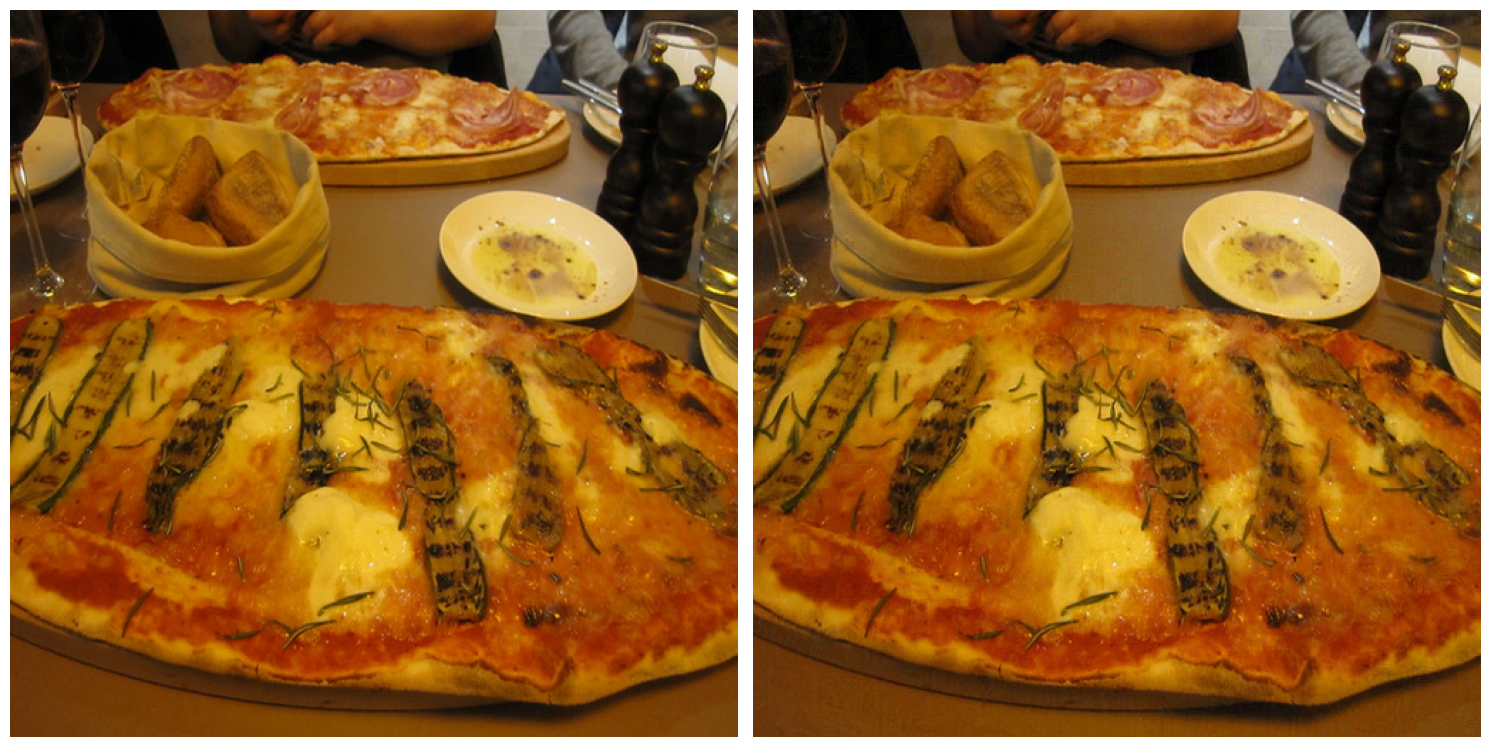

In [15]:
print(f"perturbation MSE : {torch.nn.functional.mse_loss(adv_image_tensor, image_initial)}")
print(image_initial.min(), image_initial.max(), image_initial.dtype, adv_image_tensor.dtype)
# plot_images([T.ToPILImage()(((image_initial[0][0] - 1) * 127.5)), T.ToPILImage()(((adv_image_tensor[0][0])-1)*127.5)], n_subplots=2)  
plot_images([T.ToPILImage()(image_initial[0][0]/2+0.5), T.ToPILImage()(adv_image_tensor[0][0]/2+0.5)], n_subplots=2)  

### Generate with adversarial image

In [16]:
# Create input messages
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Can you describe this image?"}
        ]
    },
]

# Prepare inputs
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[adv_image_pil], return_tensors="pt").to(device)



# Generate outputs
generated_ids = model.generate(**inputs, max_new_tokens=100)
generated_texts = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True,
)

print(generated_texts[0])

User:Can you describe this image?
Assistant: The person is sitting on a chair.


In [17]:
# adv_image_pil.save("adv.jpg")